# Spaceship Titanic — Multi-Agent Workflow Notebook

**Single notebook for all agents** on this competition. Run cells top-to-bottom within each section.

| Section | Agent | Status |
|---------|-------|--------|
| 0 | Environment & shared setup | Ready |
| 1 | Agent 1 — Data analysis (EDA) | Ready |
| 2 | Agent 2 — Data cleaning | Placeholder |
| 3 | Agent 3 — Feature engineering | Placeholder |
| 4 | Agent 4 — Modeling | Placeholder |
| 5 | Agent 5 — Validation | Placeholder |
| 6 | Agent 6 — Optimization | Placeholder |

**Kernel:** Select **Python (data_ana)** in Cursor/Jupyter (project venv at `data_ana/.venv`).

Context: [COMPETITION_BRIEF.md](./COMPETITION_BRIEF.md)


## 0. Environment & shared setup

In [1]:
# Ensure plots render in the notebook and dependencies are available
import sys
from pathlib import Path

print("Python:", sys.executable)

# If your kernel is not data_ana/.venv, install deps into the active kernel (run once)
try:
    import matplotlib
    import seaborn
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib>=3.7", "seaborn>=0.13", "pandas>=2.0", "numpy>=1.24"])
    import matplotlib
    import seaborn

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

# --- paths (all agents use these) ---
ROOT = Path("/Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic")
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
REPORTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SPEND = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
TARGET = "Transported"

assert (ROOT / "train.csv").exists(), f"Missing train.csv in {ROOT}"

train_raw = pd.read_csv(ROOT / "train.csv")
test_raw = pd.read_csv(ROOT / "test.csv")
sample_sub = pd.read_csv(ROOT / "sample_submission.csv")

print(f"ROOT: {ROOT}")
print(f"train_raw: {train_raw.shape} | test_raw: {test_raw.shape}")
display(train_raw.head())


Python: /Users/mindodoo/Projects/data_ana/.venv/bin/python3


ROOT: /Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic
train_raw: (8693, 14) | test_raw: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


---
## 1. Agent 1 — Data Intake & Initial Analysis (EDA)

Exploratory analysis on **raw** data (no cleaning yet). Downstream agents use `train_raw` / `test_raw`.


### 1.1 Problem type

In [2]:
display(Markdown('''
| Item | Value |
|------|-------|
| Task | **Binary classification** (supervised) |
| Target | `Transported` |
| Metric | Categorization Accuracy |
| Train labels | Yes |
| Test labels | No (hidden by Kaggle) |
'''))

print("Reasoning: one boolean outcome per passenger; tabular cross-sectional features.")



| Item | Value |
|------|-------|
| Task | **Binary classification** (supervised) |
| Target | `Transported` |
| Metric | Categorization Accuracy |
| Train labels | Yes |
| Test labels | No (hidden by Kaggle) |


Reasoning: one boolean outcome per passenger; tabular cross-sectional features.


### 1.2 Schema & dataset overview

In [3]:
overview = pd.DataFrame({
    "column": train_raw.columns,
    "dtype": train_raw.dtypes.astype(str).values,
    "non_null": train_raw.notnull().sum().values,
    "unique": [train_raw[c].nunique(dropna=True) for c in train_raw.columns],
    "missing_%": (train_raw.isnull().mean() * 100).round(2).values,
})
display(overview)

checks = pd.Series({
    "train rows": len(train_raw),
    "test rows": len(test_raw),
    "duplicate rows (train)": train_raw.duplicated().sum(),
    "duplicate PassengerId (train)": train_raw["PassengerId"].duplicated().sum(),
    "train/test id overlap": len(set(train_raw["PassengerId"]) & set(test_raw["PassengerId"])),
    "memory MB (train)": round(train_raw.memory_usage(deep=True).sum() / 1e6, 2),
})
display(checks.to_frame("value"))


,column,dtype,non_null,unique,missing_%
0,PassengerId,object,8693,8693,0.00
1,HomePlanet,object,8492,3,2.31
2,CryoSleep,object,8476,2,2.50
3,Cabin,object,8494,6560,2.29
4,Destination,object,8511,3,2.09
5,Age,float64,8514,80,2.06
6,VIP,object,8490,2,2.34
7,RoomService,float64,8512,1273,2.08
8,FoodCourt,float64,8510,1507,2.11
9,ShoppingMall,float64,8485,1115,2.39


,value
train rows,8693.00
test rows,4277.00
duplicate rows (train),0.00
duplicate PassengerId (train),0.00
train/test id overlap,0.00
memory MB (train),3.83


### 1.3 Target distribution

Transported
True     4378
False    4315
Name: count, dtype: int64
Transported
True     0.5036
False    0.4964
Name: proportion, dtype: float64


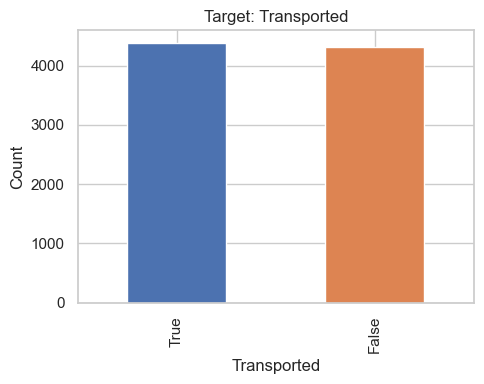

In [4]:
print(train_raw[TARGET].value_counts())
print(train_raw[TARGET].value_counts(normalize=True).round(4))

fig, ax = plt.subplots(figsize=(5, 4))
train_raw[TARGET].value_counts().plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_title("Target: Transported")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


### 1.4 Missing values

,train_%,test_%
Age,2.06,2.13
Cabin,2.29,2.34
CryoSleep,2.50,2.17
Destination,2.09,2.15
FoodCourt,2.11,2.48
HomePlanet,2.31,2.03
Name,2.30,2.20
PassengerId,0.00,0.00
RoomService,2.08,1.92
ShoppingMall,2.39,2.29


,column,p_transported_missing,p_transported_present,delta
6,RoomService,0.4586,0.5046,-0.0460
8,ShoppingMall,0.5481,0.5025,0.0455
7,FoodCourt,0.5410,0.5028,0.0382
10,VRDeck,0.5213,0.5032,0.0180
1,CryoSleep,0.4885,0.5040,-0.0155
0,HomePlanet,0.5124,0.5034,0.0090
5,VIP,0.5123,0.5034,0.0089
9,Spa,0.4973,0.5038,-0.0065
3,Destination,0.5055,0.5036,0.0019
11,Name,0.5050,0.5036,0.0014


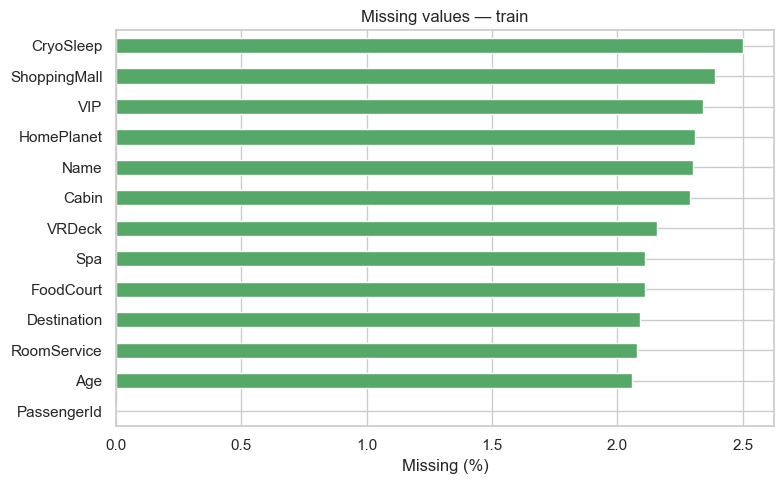

In [5]:
feature_cols = [c for c in train_raw.columns if c != TARGET]
miss_compare = pd.DataFrame({
    "train_%": train_raw[feature_cols].isnull().mean().sort_values(ascending=False) * 100,
    "test_%": test_raw.isnull().mean().sort_values(ascending=False) * 100,
}).round(2)
display(miss_compare)

rows = []
for c in feature_cols:
    if train_raw[c].isnull().any():
        m = train_raw[c].isnull()
        rows.append({
            "column": c,
            "p_transported_missing": train_raw.loc[m, TARGET].mean(),
            "p_transported_present": train_raw.loc[~m, TARGET].mean(),
            "delta": train_raw.loc[m, TARGET].mean() - train_raw.loc[~m, TARGET].mean(),
        })
display(pd.DataFrame(rows).sort_values("delta", key=abs, ascending=False).round(4))

fig, ax = plt.subplots(figsize=(8, 5))
(miss_compare["train_%"].sort_values()).plot(kind="barh", ax=ax, color="#55a868")
ax.set_xlabel("Missing (%)")
ax.set_title("Missing values — train")
plt.tight_layout()
plt.show()


### 1.5 Numeric distributions & outliers

,mean,median,std,min,max,skew,kurtosis
Age,28.83,27.0,14.49,0.0,79.0,0.42,0.10
RoomService,224.69,0.0,666.72,0.0,14327.0,6.33,65.27
FoodCourt,458.08,0.0,1611.49,0.0,29813.0,7.10,73.31
ShoppingMall,173.73,0.0,604.70,0.0,23492.0,12.63,328.87
Spa,311.14,0.0,1136.71,0.0,22408.0,7.64,81.20
VRDeck,304.85,0.0,1145.72,0.0,24133.0,7.82,86.01
TotalSpend,1440.87,716.0,2803.05,0.0,35987.0,4.42,27.48


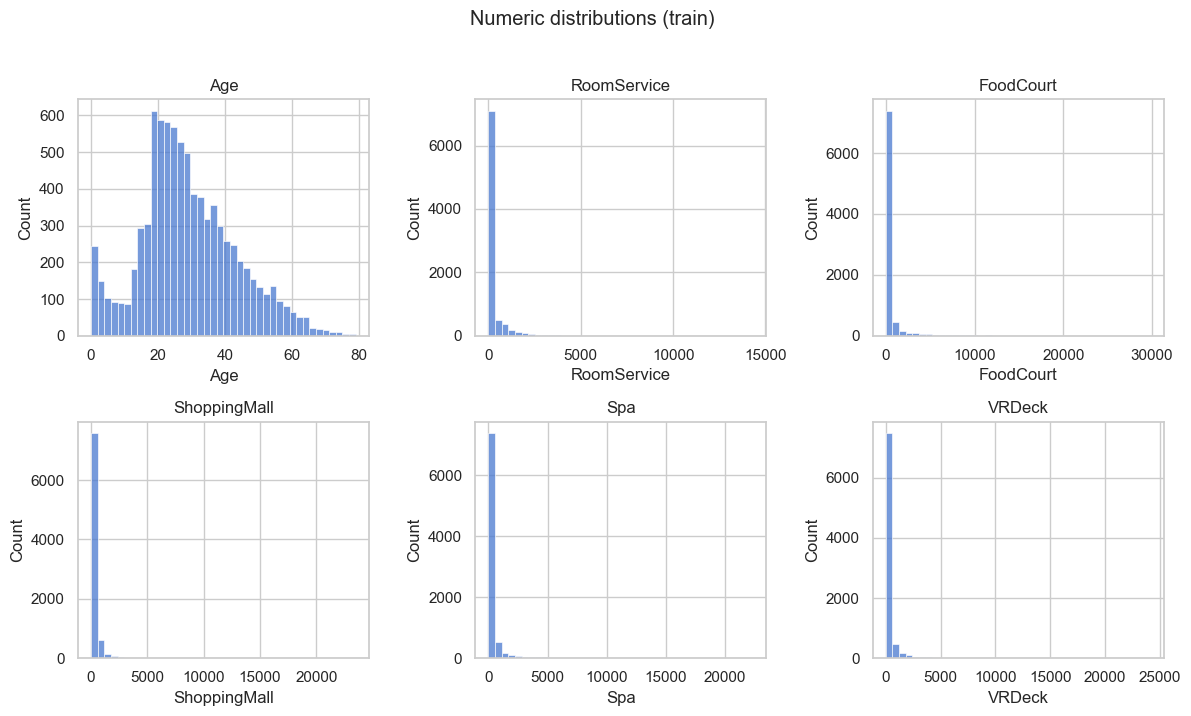

Age            0.9%
TotalSpend    10.7%
Name: IQR outlier %, dtype: object

In [6]:
eda = train_raw.copy()
eda["GroupId"] = eda["PassengerId"].str.split("_").str[0]
eda["TotalSpend"] = eda[SPEND].sum(axis=1, min_count=1)

num_cols = ["Age"] + SPEND + ["TotalSpend"]
stats = eda[num_cols].agg(["mean", "median", "std", "min", "max"]).T
stats["skew"] = eda[num_cols].skew().round(3)
stats["kurtosis"] = eda[num_cols].kurtosis().round(3)
display(stats.round(2))

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(eda[col].dropna(), bins=40, ax=ax)
    ax.set_title(col)
fig.suptitle("Numeric distributions (train)", y=1.02)
plt.tight_layout()
plt.show()

def iqr_outlier_pct(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() * 100

display(pd.Series({c: f"{iqr_outlier_pct(eda[c].dropna()):.1f}%" for c in ["Age", "TotalSpend"]}, name="IQR outlier %"))


### 1.6 Categorical features & transport rates


=== HomePlanet ===


,P(Transported)
HomePlanet,
Europa,0.659
Mars,0.523
NaN,0.512
Earth,0.424



=== CryoSleep ===


,P(Transported)
CryoSleep,
True,0.818
NaN,0.488
False,0.329



=== Destination ===


,P(Transported)
Destination,
55 Cancri e,0.610
NaN,0.505
PSO J318.5-22,0.504
TRAPPIST-1e,0.471



=== VIP ===


,P(Transported)
VIP,
NaN,0.512
False,0.506
True,0.382



=== Cabin Side ===


,P(Transported)
Side,
P,0.451
S,0.555
NaN,0.503


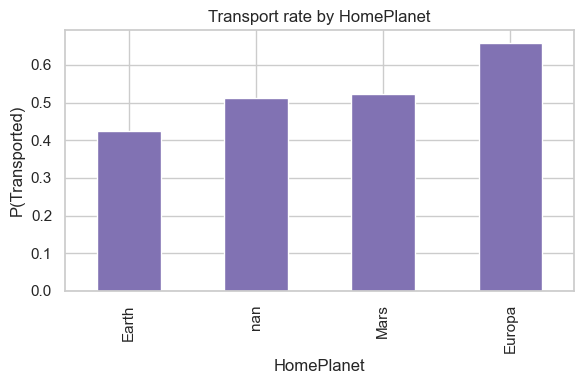

In [7]:
for col in ["HomePlanet", "CryoSleep", "Destination", "VIP"]:
    print(f"\n=== {col} ===")
    display(train_raw.groupby(col, dropna=False)[TARGET].mean().sort_values(ascending=False).round(3).to_frame("P(Transported)"))

parts = train_raw["Cabin"].dropna().astype(str).str.split("/", expand=True)
eda.loc[train_raw["Cabin"].notna(), "Deck"] = parts[0].values
eda.loc[train_raw["Cabin"].notna(), "Side"] = parts[2].values
print("\n=== Cabin Side ===")
display(eda.groupby("Side", dropna=False)[TARGET].mean().round(3).to_frame("P(Transported)"))

fig, ax = plt.subplots(figsize=(6, 4))
train_raw.groupby("HomePlanet", dropna=False)[TARGET].mean().sort_values().plot(kind="bar", ax=ax, color="#8172b3")
ax.set_ylabel("P(Transported)")
ax.set_title("Transport rate by HomePlanet")
plt.tight_layout()
plt.show()


### 1.7 Group structure (PassengerId)

In [8]:
eda["GroupSize"] = eda.groupby("GroupId")["PassengerId"].transform("count")
print("Unique groups:", eda["GroupId"].nunique())
display(eda["GroupSize"].value_counts().sort_index().head(10).to_frame("passengers"))
display(eda.groupby("GroupSize")[TARGET].mean().round(3).to_frame("P(Transported)"))


Unique groups: 6217


,passengers
GroupSize,
1,4805
2,1682
3,1020
4,412
5,265
6,174
7,231
8,104


,P(Transported)
GroupSize,
1,0.452
2,0.538
3,0.593
4,0.641
5,0.592
6,0.615
7,0.541
8,0.394


### 1.8 Correlations

,spearman
TotalSpend,-0.419
Spa,-0.373
RoomService,-0.371
VRDeck,-0.352
ShoppingMall,-0.229
FoodCourt,-0.187
Age,-0.071


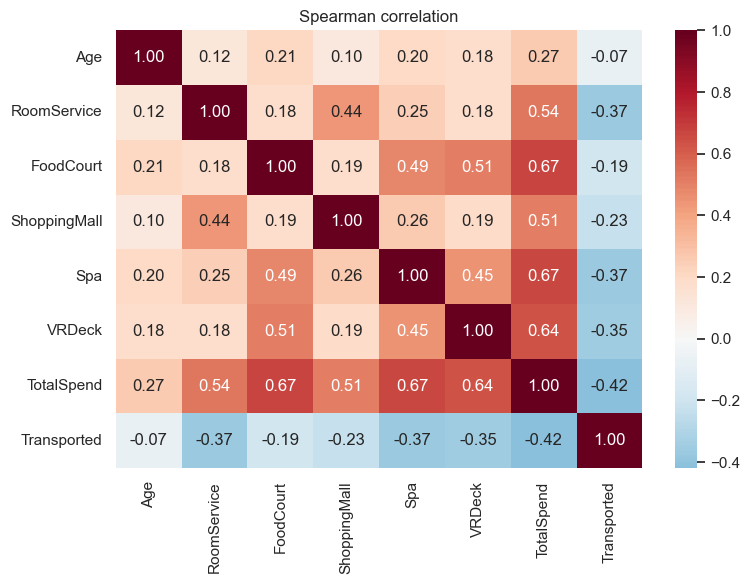

Max spend pairwise corr: 0.228


In [9]:
num = eda[num_cols].copy()
num[TARGET] = eda[TARGET].astype(int)

display(num.corr(method="spearman")[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3).to_frame("spearman"))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(num.corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Spearman correlation")
plt.tight_layout()
plt.show()

print("Max spend pairwise corr:", eda[SPEND].corr().where(~np.eye(len(SPEND), dtype=bool)).stack().max().round(3))


### 1.9 Leakage & risk checks

In [10]:
risk = pd.Series({
    "PassengerId unique (train)": train_raw["PassengerId"].is_unique,
    "PassengerId unique (test)": test_raw["PassengerId"].is_unique,
    "No train/test id overlap": len(set(train_raw["PassengerId"]) & set(test_raw["PassengerId"])) == 0,
    "Target has no nulls": train_raw[TARGET].notnull().all(),
})
display(risk.to_frame("ok"))

display(Markdown('''
**Agent 1 summary (handoff to Agent 2):**
- CryoSleep=True → much higher transport rate (~82% vs ~33% when False)
- HomePlanet / Destination strong univariate signals
- Spend negatively correlated with transport
- ~2% missing per column; missing spend may be MNAR
- Parse Cabin; use group features with fold-safe CV
'''))


,ok
PassengerId unique (train),True
PassengerId unique (test),True
No train/test id overlap,True
Target has no nulls,True



**Agent 1 summary (handoff to Agent 2):**
- CryoSleep=True → much higher transport rate (~82% vs ~33% when False)
- HomePlanet / Destination strong univariate signals
- Spend negatively correlated with transport
- ~2% missing per column; missing spend may be MNAR
- Parse Cabin; use group features with fold-safe CV


### 1.10 Agent 1 — optional export markdown reports

In [11]:
# Writes reports/ for audit trail; primary results are in cells above.
from datetime import date

def write_agent1_reports():
    miss_lines = []
    for c in feature_cols:
        if train_raw[c].isnull().any():
            m = train_raw[c].isnull()
            miss_lines.append(
                f"| {c} | {train_raw[c].isnull().mean()*100:.2f}% | "
                f"{train_raw.loc[m, TARGET].mean():.3f} | {train_raw.loc[~m, TARGET].mean():.3f} | "
                f"{train_raw.loc[m, TARGET].mean() - train_raw.loc[~m, TARGET].mean():+.3f} |"
            )
    spearman = num.corr(method="spearman")[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

    (REPORTS / "initial_analysis.md").write_text(
        f"# Initial Analysis — Agent 1\n\nGenerated {date.today()} from `spaceship_titanic_agents.ipynb`.\n\n"
        f"Train {len(train_raw):,} rows; target balance {train_raw[TARGET].mean():.2%} True.\n"
        f"See notebook section 1 for full tables and plots.\n",
        encoding="utf-8",
    )
    (REPORTS / "correlation_report.md").write_text(
        "# Correlation Report\n\n" + spearman.round(3).to_string() + "\n",
        encoding="utf-8",
    )
    fig, ax = plt.subplots(figsize=(5, 4))
    train_raw[TARGET].value_counts().plot(kind="bar", ax=ax)
    fig.savefig(FIGURES / "target_distribution.png", dpi=120, bbox_inches="tight")
    plt.close(fig)
    print("Wrote:", REPORTS / "initial_analysis.md")

write_agent1_reports()


Wrote: /Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic/reports/initial_analysis.md


---
## 2. Agent 2 — Data Cleaning & Transformation

This section runs **Agent 2** cleaning/transformation to produce `train_clean`, `test_clean`, and `cleaned_dataset` in-cell.

**It also writes**:
- `reports/cleaning_report.md`
- `reports/transformation_report.md`
- `reports/outlier_report.md`
- `reports/encoding_report.md`
- `reports/cleaned_dataset.parquet`


In [12]:
# Agent 2: run cleaning/transformation (in-cell)
from __future__ import annotations

import sys
from pathlib import Path

assert "train_raw" in globals(), "Run section 0 first (defines train_raw/test_raw)."
assert "test_raw" in globals(), "Run section 0 first (defines train_raw/test_raw)."

ROOT = Path("/Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic")
sys.path.insert(0, str(ROOT / "scripts"))

from run_agent2_cleaning import run_agent2_cleaning

train_clean, test_clean, cleaned_dataset = run_agent2_cleaning(train_raw, test_raw)

print("train_clean:", train_clean.shape, "| test_clean:", test_clean.shape)
print("cleaned_dataset:", cleaned_dataset.shape)
display(cleaned_dataset["split"].value_counts().to_frame("count"))

print("\nNull rates (top 15) — train_clean:")
display(train_clean.isnull().mean().sort_values(ascending=False).head(15).to_frame("null_rate"))

print("\nPreview train_clean:")
display(train_clean.head(3))

print("\nWrote parquet + markdown reports into:", ROOT / "reports")


train_clean: (8693, 30) | test_clean: (4277, 29)
cleaned_dataset: (12970, 31)


/Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic/scripts/run_agent2_cleaning.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train[col] = train[col].fillna(fill_value).astype(bool).astype(int)
/Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic/scripts/run_agent2_cleaning.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test[col] = test[col].fillna(fill_value).astype(bool).astype(int)
/Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic/scripts/run_agent2_cleaning.py:83: FutureWarning: Downcasting object dtype arr

,count
split,
train,8693
test,4277



Null rates (top 15) — train_clean:


,null_rate
PassengerId,0.0
HomePlanet,0.0
VRDeck_is_missing,0.0
Spa_is_missing,0.0
ShoppingMall_is_missing,0.0
FoodCourt_is_missing,0.0
RoomService_is_missing,0.0
CabinNum_is_missing,0.0
Side_is_missing,0.0
Deck_is_missing,0.0



Preview train_clean:


,PassengerId,HomePlanet,CryoSleep,Deck,CabinNum,Side,Destination,Age,VIP,RoomService,...,Age_is_missing,Deck_is_missing,Side_is_missing,CabinNum_is_missing,RoomService_is_missing,FoodCourt_is_missing,ShoppingMall_is_missing,Spa_is_missing,VRDeck_is_missing,Transported
0,0001_01,Europa,0,B,0.0,P,TRAPPIST-1e,39.0,0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,0002_01,Earth,0,F,0.0,S,TRAPPIST-1e,24.0,0,109.0,...,False,False,False,False,False,False,False,False,False,True
2,0003_01,Europa,0,A,0.0,S,TRAPPIST-1e,58.0,1,43.0,...,False,False,False,False,False,False,False,False,False,False



Wrote parquet + markdown reports into: /Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic/reports


---
## 3. Agent 3 — Feature Engineering

This section runs **Agent 3** feature engineering on `train_clean` / `test_clean`.

**Outputs written to `reports/`:**
- `engineered_features.parquet`
- `feature_registry.md`
- `feature_engineering_report.md`
- `feature_selection_report.md`
- `correlation_optimization_report.md`
- `feature_importance_report.md`


In [13]:
# Agent 3: feature engineering + feature importance
from __future__ import annotations

import sys
from pathlib import Path

assert "train_clean" in globals(), "Run section 2 first (Agent 2 cleaning)."
assert "test_clean" in globals(), "Run section 2 first (Agent 2 cleaning)."

ROOT = Path("/Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic")
sys.path.insert(0, str(ROOT / "scripts"))

from run_agent3_feature_engineering import run_agent3

agent3 = run_agent3(train_clean, test_clean)
train_fe = agent3["train_fe"]
test_fe = agent3["test_fe"]
importance = agent3["importance"]
meta = agent3["meta"]

print("Agent 3 complete.")
print("Holdout accuracy (quick check):", round(meta["holdout_accuracy"], 4))
print("Engineered parquet:", agent3["parquet_path"])

print("\nTop 25 permutation importances:")
display(importance.head(25))

print("\nEngineered train shape:", train_fe.shape, "| Engineered test shape:", test_fe.shape)
display(train_fe.head(3))


Agent 3 complete.
Holdout accuracy (quick check): 0.8108
Engineered parquet: /Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic/reports/engineered_features.parquet

Top 25 permutation importances:


,feature,importance_mean,importance_std
12,VRDeck,0.038585,0.005578
9,FoodCourt,0.033007,0.004792
11,Spa,0.030880,0.005808
13,TotalSpend,0.030592,0.006413
41,DeckSide,0.020012,0.003351
1,CryoSleep,0.017021,0.006103
3,CabinNum,0.015296,0.002442
8,RoomService,0.013744,0.002915
10,ShoppingMall,0.008798,0.004131
4,Side,0.008511,0.002569



Engineered train shape: (8693, 52) | Engineered test shape: (4277, 51)


,PassengerId,HomePlanet,CryoSleep,Deck,CabinNum,Side,Destination,Age,VIP,RoomService,...,VIP_and_HighSpend,DeckSide,AgeBin,GroupSize_all,GroupTotalSpend_all,GroupMeanAge_all,GroupAnyVIP_all,GroupAnyCryo_all,GroupSpendPerPerson_all,GroupIsSolo_all
0,0001_01,Europa,0,B,0.0,P,TRAPPIST-1e,39.0,0,0.0,...,0,B_P,4,1,0.0,39.0,0,0,0.0,1
1,0002_01,Earth,0,F,0.0,S,TRAPPIST-1e,24.0,0,109.0,...,0,F_S,2,1,736.0,24.0,0,0,736.0,1
2,0003_01,Europa,0,A,0.0,S,TRAPPIST-1e,58.0,1,43.0,...,1,A_S,5,2,15559.0,45.5,1,0,7779.5,0


---
## 4. Agent 4 — Modeling

### Agent 4 — Model recommendation (pause for approval)

This section proposes a primary model based on a quick holdout accuracy comparison.

Outputs:
- `reports/model_selection_report.md`
- A printed candidate comparison table

**Stop point:** After the recommendation is shown, we will ask you to approve before Agent 5 starts tuning/training with proper CV.

In [14]:
# Agent 4: recommend a model (no full training beyond holdout ranking)
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path("/Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic")
sys.path.insert(0, str(ROOT / "scripts"))

from run_agent4_model_selection import main as run_agent4

run_agent4()

print("\nPlease review reports/model_selection_report.md and approve the primary model before we proceed to Agent 5.")


/Users/mindodoo/Projects/data_ana/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mindodoo/Projects/data_ana/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mindodoo/Projects/data_ana/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mindodoo/Projects/data_ana/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Candidate model comparison (holdout accuracy):
                                    model  holdout_accuracy
HistGradientBoostingClassifier(OHE dense)          0.807361
                  LogisticRegression(OHE)          0.784359

Primary recommendation:
HistGradientBoostingClassifier(OHE dense)

Alternatives to revisit (Agent 5/6):
- LogisticRegression(OHE)

Wrote: /Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic/reports/model_selection_report.md

Please review reports/model_selection_report.md and approve the primary model before we proceed to Agent 5.


---
## 5. Agent 5 — Validation & QA

This section runs **group-safe validation** for the approved primary model.

Outputs (written to `reports/`):
- `validation_report.md`
- `error_analysis_report.md`
- `qa_report.md`
- `robustness_report.md`
- `deployment_readiness.md`


In [15]:
# Agent 5: group-safe validation and QA
from __future__ import annotations

import sys
from pathlib import Path

assert "train_clean" in globals(), "Run section 2 first (Agent 2 cleaning)."

ROOT = Path("/Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic")
sys.path.insert(0, str(ROOT / "scripts"))

from run_agent5_validation import run_agent5

agent5 = run_agent5(train_clean)
fold_df = agent5["fold_df"]
overall = agent5["overall"]

print("Agent 5 complete.")
display(fold_df.round(4))
print("\nOverall OOF metrics:")
display(pd.Series(overall).round(4).to_frame("value"))
print("\nReports written to:", ROOT / "reports")


Agent 5 complete.


,fold,n_train,n_val,accuracy,f1,precision,recall,roc_auc
0,1,6954,1739,0.8028,0.8028,0.7914,0.8145,0.8965
1,2,6954,1739,0.8131,0.8062,0.8325,0.7815,0.8963
2,3,6954,1739,0.8120,0.8186,0.8110,0.8264,0.9051
3,4,6955,1738,0.8078,0.8035,0.8319,0.7770,0.9048
4,5,6955,1738,0.7986,0.8060,0.7902,0.8224,0.8939



Overall OOF metrics:


,value
accuracy,0.8069
f1,0.8075
precision,0.8106
recall,0.8045
roc_auc,0.8990



Reports written to: /Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic/reports


---
## 6. Agent 6 — Retraining & Optimization

Hyperparameter tuning for the approved `HistGradientBoostingClassifier` pipeline.

- Uses **GroupKFold** by `GroupId` (group-safe)
- Optimizes **OOF accuracy** (Kaggle test labels are hidden locally)
- **`submission.csv` is ON HOLD** — not generated in this section

Outputs: `reports/retraining_report.md`, `model_comparison.md`, `iteration_history.md`, `final_recommendations.md`, `optimized_model/best_pipeline.joblib`


In [16]:
# Agent 6: hyperparameter tuning (submission on hold)
from __future__ import annotations

import sys
from pathlib import Path

assert "train_clean" in globals(), "Run section 2 first."

ROOT = Path("/Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic")
sys.path.insert(0, str(ROOT / "scripts"))

from run_agent6_optimization import Agent6Cfg, run_agent6

agent6 = run_agent6(train_clean, cfg=Agent6Cfg(root=ROOT, n_iter=24, generate_submission=False))

print("\n=== Agent 6 summary ===")
print("Baseline OOF accuracy:", round(agent6["baseline_oof"]["accuracy"], 4))
print("Tuned OOF accuracy:", round(agent6["tuned_oof"]["accuracy"], 4))
print("Delta:", round(agent6["tuned_oof"]["accuracy"] - agent6["baseline_oof"]["accuracy"], 4))
print("\nBest params:")
display(pd.Series(agent6["best_params"]))
print("\nTop search trials:")
display(agent6["cv_results_top"])
print("\nSaved model:", agent6["model_dir"] / "best_pipeline.joblib")
print("submission.csv: ON HOLD (not generated)")


Agent 6 not implemented yet.


### 6.1 Improvement review (keeps saved tuned model unchanged)

Runs additional experiments and writes `reports/improvement_opportunities.md`.


In [ ]:
import sys
from pathlib import Path

ROOT = Path("/Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic")
sys.path.insert(0, str(ROOT / "scripts"))
from run_improvement_review import main as run_improvement_review

run_improvement_review()


### 6.2 Generate submission.csv (first submission — canonical HGB)


In [ ]:
import sys
from pathlib import Path

assert "train_clean" in globals() and "test_clean" in globals()
ROOT = Path("/Users/mindodoo/Projects/data_ana/notebooks/spaceship-titanic")
sys.path.insert(0, str(ROOT / "scripts"))
from run_generate_submission import generate_submission

sub_path = generate_submission(train_clean, test_clean, root=ROOT)
display(pd.read_csv(sub_path).head())


### 6.3 Extended tuning — LightGBM & CatBoost

40 trials each, group-safe CV. Requires `libomp` on macOS (`brew install libomp`). Writes `reports/extended_tuning_report.md`.


In [ ]:
from run_agent6_extended_tuning import ExtendedCfg, run_extended_tuning

extended = run_extended_tuning(train_clean, cfg=ExtendedCfg(root=ROOT, n_iter_lgbm=40, n_iter_catboost=40))
display(extended["comparison"])


### 6.4 CatBoost — native categoricals (no OHE)

50-trial group-safe search. Writes `submission_catboost_native.csv` and `reports/catboost_native_report.md`.


In [ ]:
from run_agent6_catboost_native import CatBoostNativeCfg, run_catboost_native

cb = run_catboost_native(train_clean, test_clean, cfg=CatBoostNativeCfg(root=ROOT, n_iter=50))
print("OOF:", round(cb["best_oof"], 4), "| threshold:", cb["threshold"])
print("Submission:", cb["submission_path"])
display(cb["history"].head(10))


### 6.5 Advanced feature pass v2 (post CatBoost-native)

Runs Agent 3 advanced features script and writes:
- `reports/feature_engineering_report_v2.md`
- `reports/feature_selection_report_v2.md`
- `reports/correlation_optimization_report_v2.md`
- `reports/feature_importance_report_v2.md`
- `reports/advanced_feature_comparison.md`

In [ ]:
from run_agent3_advanced_features import main as run_agent3_advanced

run_agent3_advanced()

print((ROOT / "reports" / "advanced_feature_comparison.md").read_text())

### 6.6 OOF error metrics table (Accuracy, ROC-AUC, MSE/Brier, MAE, logloss)

Kaggle test labels are hidden, so this uses group-safe OOF predictions as proxy.

In [ ]:
from run_stacked_ensemble import run_stacking
from sklearn.metrics import mean_squared_error, mean_absolute_error, log_loss, roc_auc_score, accuracy_score

stack_res = run_stacking()
oof = pd.read_parquet(ROOT / "reports" / "stacked_oof_predictions.parquet")

y = oof["y"].astype(float).to_numpy()
models = {
    "HGB baseline": "p_hgb",
    "CatBoost native": "p_cat",
    "Stacked ensemble": "p_stack",
}
rows = []
for name, col in models.items():
    p = oof[col].astype(float).to_numpy().clip(1e-7, 1 - 1e-7)
    pred = (p >= 0.5).astype(int)
    rows.append(
        {
            "model": name,
            "oof_accuracy@0.5": accuracy_score(y, pred),
            "oof_roc_auc": roc_auc_score(y, p),
            "mse_prob": mean_squared_error(y, p),
            "mae_prob": mean_absolute_error(y, p),
            "log_loss": log_loss(y, p),
            "brier_score": mean_squared_error(y, p),
        }
    )

metrics_df = pd.DataFrame(rows).sort_values("oof_accuracy@0.5", ascending=False)
display(metrics_df.round(6))

### 6.7 Baseline-only iteration pack (threshold sweep)

Generates multiple baseline submission candidates using tuned HGB with different thresholds.

In [ ]:
from run_baseline_iterations import run_iterations

baseline_iter = run_iterations()
display(baseline_iter["top_thresholds"].round(6))
print("Best baseline alias:", baseline_iter["best_alias"])

### 6.8 Iteration Pack #1 — group-aware blend search

Searches blend weights across HGB/CatBoost/Stacked and writes ranked candidates + submission files.

In [ ]:
from run_iteration_pack1_blends import run_pack1

top_blends, blend_files = run_pack1()
display(top_blends.round(6))
print("Generated blend submissions:")
for f in blend_files:
    print(" -", f)

### 6.9 Leakage-safe stack v2 (strict OOF stacking)

This pipeline avoids train+test combined aggregates and uses strict two-level GroupKFold OOF stacking.

Outputs:
- `reports/stacked_ensemble_safe_v2_report.md`
- `reports/stacked_safe_v2_oof.parquet`
- `submission_stacked_safe_v2.csv`
- `submission_stacked_safe_v2_t0.500.csv`

In [ ]:
from run_stacked_ensemble_safe_v2 import run_safe_v2

safe_v2 = run_safe_v2()
display(safe_v2["comparison"].round(6))
print("Best threshold:", safe_v2["best_threshold"])
print("Submission:", safe_v2["submission_best"])
print("Submission@0.5:", safe_v2["submission_05"])

In [ ]:
print((ROOT / "reports" / "stacked_ensemble_safe_v2_report.md").read_text())